# The scary Netflix policy that worked 🔐📈
### The 2023 "password crackdown" was supposed to spike churn. Instead it became an upside surprise. Was that a *tradable* signal?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Upside surprise%3F: 1 of 5 events](https://img.shields.io/badge/Upside_surprise%3F-1_of_5_events-8b949e?style=flat-square)

For years, Netflix let password sharing slide. Then in 2022–23 it started **charging for it** — the "password crackdown". Wall Street was sure this would drive furious customers out the door. It didn't: subscribers *grew*, and by the Q3 2023 earnings the stock jumped ~16% in a day.

That's a great story. But this desk asks a narrower, colder question: around the **five public dates** of the crackdown saga, did NFLX actually deliver an **abnormal return** you could have traded — or is "the scary policy that worked" a *business* fact that never was a *market* signal? With only **five events**, we already know the honest answer will be humble.

> 📓 **Want the market-model math, the placebo and the cost sweep?** See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from nflx_crackdown import data, strategy as st

EVENTS = data.event_table()
HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX = data.load_real()
    R_N = st.daily_returns(PX["NFLX"]); R_S = st.daily_returns(PX["SPY"]); R_Q = st.daily_returns(PX["QQQ"])
else:
    PX = R_N = R_S = R_Q = None
print("real cache present:", HAVE_REAL, "| crackdown dates in table:", len(EVENTS))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_events': 5, 'cal_lo': '2022-04-20', 'cal_hi': '2023-10-19', 'ev': {'2022-04-20': (-34.55, 1.6, "Q1'22 letter first flags paid-sharing (sub miss)"), '2022-08-22': (-2.34, 1.66, "LatAm 'add-a-home' test"), '2023-05-23': (-0.34, 1.5, 'broad US rollout'), '2023-07-20': (-7.64, 1.37, "Q2'23 +5.9M subs (rev miss)"), '2023-10-19': (17.34, 1.55, "Q3'23 +8.8M subs — the payoff")}, 'day0_mean_pct': -5.51, 'day0_t': -0.657, 'hit': 1, 'hit_n': 5, 'wilson': (4.0, 62.0), 'boot_lo': -21.7, 'boot_hi': 8.4, 'wincar_mean_pct': -4.01, 'wincar_t': -0.383, 'postcar_mean_pct': 1.39, 'postcar_t': 0.447, 'qqq_day0_mean_pct': -4.79, 'qqq_day0_t': -0.594, 'placebo_mean_pct': -0.01, 'placebo_sd_pct': 1.07, 'placebo_p_right': 0.998, 'placebo_p_left': 0.003, 'placebo_draws': 4000, 'drop_crash_mean_pct': 1.75, 'drop_crash_t': 0.324, 'drop_crash_n': 4, 'conf_mean_pct': 4.85, 'conf_t': 0.388, 'conf_n': 2, 'timer': {1: (-87.7, -107.7, -1.06, 20, 12.9), 3: (65.4, 45.4, 0.19, 60, 39.6), 5: (-231.9, -251.9, -0.56, 40, 66.6), 10: (62.7, 42.7, 0.11, 40, 134.0), 21: (264.7, 244.7, 0.34, 60, 277.0)}, 'syn_null_mean_t': 0.37, 'syn_null_sd_t': 1.06, 'syn_null_fire': 1, 'syn_planted_pct': 2.86, 'syn_planted_t': 11.12, 'fp_nflx': '5fff2e717a0c', 'fp_spy': 'da459bd64b22', 'fp_qqq': 'f8f1d5c5542a'}


real cache present: True | crackdown dates in table: 5


## The answer first

| Question | Answer |
|---|---|
| Did NFLX pop on the average crackdown date? | **No.** The average event-day *abnormal* return (stripping out the market) is **-5.5%** — and it's *negative*, dragged down by the 2022 announcement crash. |
| Is that a real signal, or one outlier? | **One outlier.** Drop the single 2022-04 crash and the other four average **+1.8%** — basically nothing. |
| Was there *any* upside surprise? | **Yes — exactly once.** Only **1 of 5** events was an up-day: the Q3'23 confirmation (**+17%** abnormal). The policy worked; the *stock reaction* was a single spike, not a pattern. |
| Could you have traded it? | **No.** Buying NFLX after each event and holding never reliably beats just owning the stock — the point estimates are all over the place, none significant. |

> A famous "it worked!" narrative — real as a business outcome, invisible as a five-event trading edge.

## 1 · The claim

> *"The password crackdown was the policy everyone said would backfire. Churn would spike, growth would stall. Instead Netflix added millions of subscribers — the scary policy quietly became the growth story of 2023, and the stock re-rated as the market realised it."*

This is a real, well-documented corporate turnaround. The **five market-facing dates** are matters of public record — the Q1'22 shareholder letter that first flagged paid-sharing (amid the sub miss that crashed the stock), the 2022-08 LatAm test, the 2023-05 broad US rollout, and the Q2/Q3'23 letters that confirmed the subscriber gains.

## 2 · So what?

"The policy worked" and "there was a tradable abnormal return around the policy" are **two different claims**. Subscriber growth is a slow business fact; a stock reaction is a fast, one-day event. We measure the second one properly — NFLX's return on each event session with the market's move *removed* (a market model), so we're not just re-discovering "tech went up in 2023".

## 3 · How would we even know?

- **The calendar.** **5** public crackdown dates, 2022-04-20 → 2023-10-19, hardcoded from the Netflix letters/newsroom (earnings print after the close, so the reaction is the next session).
- **The yardstick.** NFLX's return on each event session **minus** what a market model (fit on the prior ~6 months vs SPY) says it *should* have done — the abnormal return.
- **The luck check.** Draw 5 random dates instead, 4,000 times — is the real five-date average unusual, or just what a random handful of days looks like?
- **The trade check.** Buy NFLX at each event close, hold a few sessions, pay costs, compare to simply holding NFLX.

## 4 · The teardown — let's actually look

**First, the five events, one bar each.** Abnormal return on each event session (market removed). Notice the shape of the story.

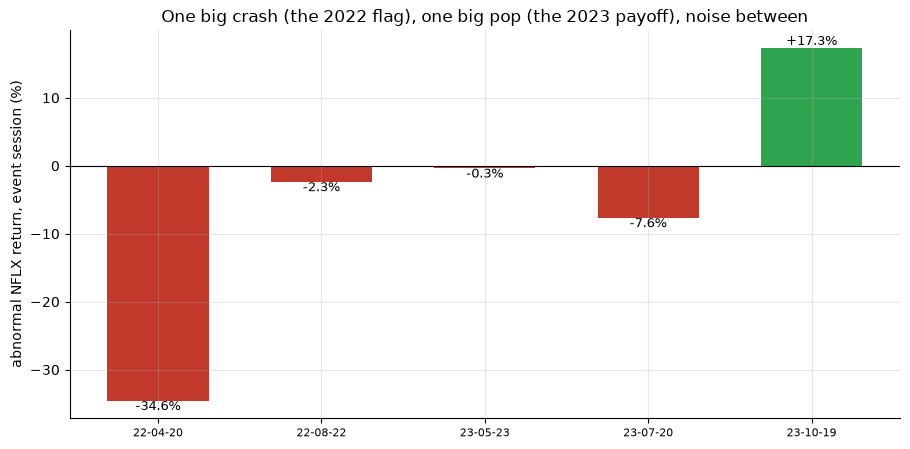

event-day abnormal returns (%): [np.float64(-34.6), np.float64(-2.3), np.float64(-0.3), np.float64(-7.6), np.float64(17.3)]


In [2]:
labels = list(R['ev'].keys())
if HAVE_REAL:
    mat, kept, _ = st.event_car(R_N, R_S, EVENTS['date'], pre=1, post=5, model='market')
    vals = [row[1] * 100 for row in mat]
    labels = [d.strftime('%Y-%m-%d') for d in kept]
else:
    vals = [R['ev'][k][0] for k in labels]
fig, ax = plt.subplots(figsize=(9.2, 4.6))
cols = [GREEN if v > 0 else RED for v in vals]
ax.bar(range(len(vals)), vals, color=cols, width=.62)
for i, v in enumerate(vals):
    ax.annotate(f'{v:+.1f}%', (i, v), ha='center', va='bottom' if v > 0 else 'top', fontsize=9)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(range(len(vals)))
ax.set_xticklabels([l[2:] for l in labels], rotation=0, fontsize=8)
ax.set_ylabel('abnormal NFLX return, event session (%)')
ax.set_title('One big crash (the 2022 flag), one big pop (the 2023 payoff), noise between')
plt.tight_layout(); plt.show()
print('event-day abnormal returns (%):', [round(v,1) for v in vals])

The picture *is* the finding: the 2022-04 announcement was a **-35%** abnormal crash (Netflix flagged the policy in the same breath as its first subscriber decline in a decade), the Q3'23 confirmation was a **+17%** pop, and the three middle dates were noise. "The policy worked" is true — but the market reaction was **one crash and one pop**, not a repeatable signal.

**Now average them and ask if it's distinguishable from luck.**

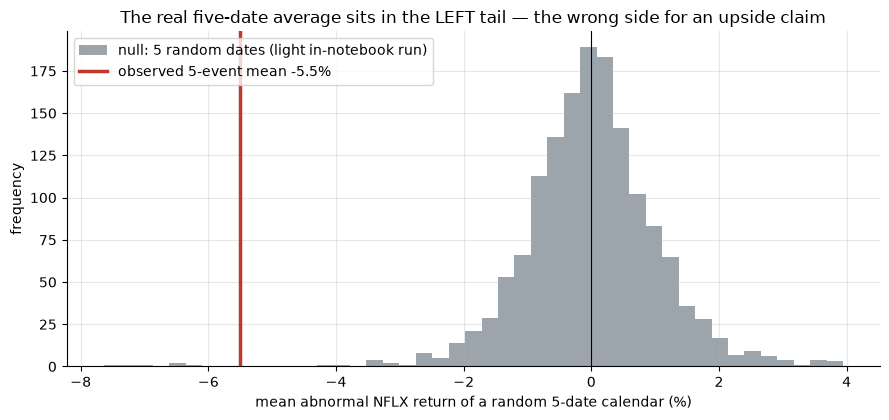

observed -5.51%  vs random-calendar mean -0.01% (sd 1.07%); canonical left-tail p = 0.003


In [3]:
if HAVE_REAL:
    d0 = st.day0_stats(R_N, R_S, EVENTS['date'], model='market')
    obs = d0['mean'] * 100
    pl = st.placebo_distribution(R_N, R_S, d0['n'], model='market', n_draws=1500, seed=851)
    draws = pl * 100
else:
    obs = R['day0_mean_pct']
    rng = np.random.default_rng(851)
    draws = rng.normal(R['placebo_mean_pct'], R['placebo_sd_pct'], 1500)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=45, color=GREY, alpha=.85, label='null: 5 random dates (light in-notebook run)')
ax.axvline(obs, c=RED, lw=2.5, label=f'observed 5-event mean {obs:+.1f}%')
ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('mean abnormal NFLX return of a random 5-date calendar (%)')
ax.set_ylabel('frequency')
ax.set_title('The real five-date average sits in the LEFT tail — the wrong side for an upside claim')
ax.legend(); plt.tight_layout(); plt.show()
print(f"observed {obs:+.2f}%  vs random-calendar mean {R['placebo_mean_pct']:+.2f}% "
      f"(sd {R['placebo_sd_pct']:.2f}%); canonical left-tail p = {R['placebo_p_left']:.3f}")

> Because one −35% crash sits in the sample, the *average* of the five is actually **negative** (-5.5%) and lands in the **left** tail of the random-calendar null — the opposite direction from the "upside surprise" the story promises. That's not evidence of a *downside* edge either; it's what happens when one outlier dominates a five-point average. The honest read is simply: **five events can't tell you much.**

**Finally, could you have traded it?**

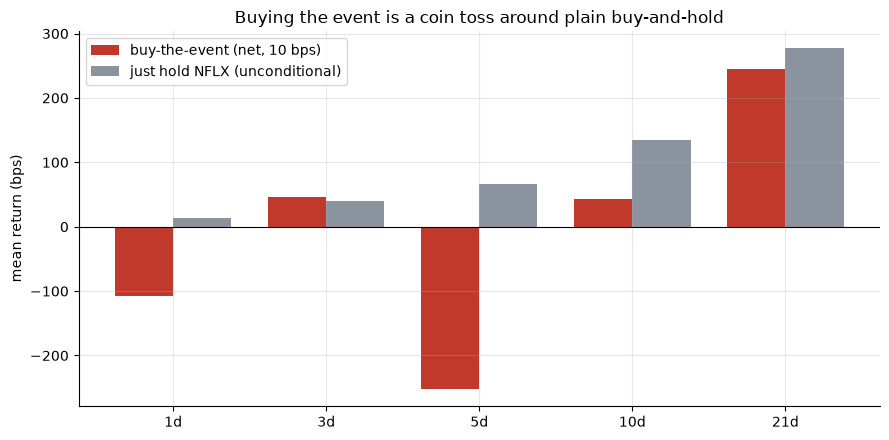

net buy-the-event (bps): {1: -108, 3: 45, 5: -252, 10: 43, 21: 245}
unconditional NFLX (bps): {1: 13, 3: 40, 5: 67, 10: 134, 21: 277}


In [4]:
holds = sorted(R['timer'])
if HAVE_REAL:
    net, base = [], []
    for h in holds:
        n10 = st.summarize_trade(st.buy_the_event(PX['NFLX'], EVENTS['date'], hold=h, cost_bps=10.0), 'ret_net')
        net.append(n10['mean_bps'])
        base.append(float((PX['NFLX'].shift(-h) / PX['NFLX'] - 1.0).mean() * 1e4))
else:
    net = [R['timer'][h][1] for h in holds]
    base = [R['timer'][h][4] for h in holds]
fig, ax = plt.subplots(figsize=(9.0, 4.5))
x = np.arange(len(holds)); w = 0.38
ax.bar(x - w/2, net, width=w, color=RED, label='buy-the-event (net, 10 bps)')
ax.bar(x + w/2, base, width=w, color=GREY, label='just hold NFLX (unconditional)')
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in holds])
ax.set_ylabel('mean return (bps)')
ax.set_title('Buying the event is a coin toss around plain buy-and-hold')
ax.legend(); plt.tight_layout(); plt.show()
print('net buy-the-event (bps):', dict(zip(holds, [round(v) for v in net])))
print('unconditional NFLX (bps):', dict(zip(holds, [round(v) for v in base])))

At every horizon the "buy the crackdown event" trade is indistinguishable from — often worse than — simply owning NFLX, with win rates from 20% to 60% on five trades. There is no edge here to bank.

## 5 · The verdict

- **Signal — None.** The average crackdown-date abnormal return is **-5.5%** (*t* = -0.66); the entire result is one 2022 crash and one 2023 pop. Only 1 of 5 events was the promised upside. As a *tradable news signal*, it isn't there.
- **Tradability — Mirage.** No horizon beats buy-and-hold; five trades can't clear costs or significance.
- **"The scary policy that worked?" — true, but as a business fact, not a market edge.** Subscribers grew; the stock's reaction was a single spike you couldn't have known to catch in advance.

## 6 · Going further 🚪

- **This is a case study, not a factor.** Five events is far too few for statistics; the value here is the *anatomy*, not a *t*-stat. Don't read the negative average as a short signal — read it as "one outlier, no power."
- **Where a real version might live:** a *portfolio* of many "feared-policy-that-worked" corporate events across names and years, so the sample size can actually support inference.
- **Sibling studies:** [551-netflix-top10](../../551-netflix-top10/) (a different NFLX signal — the Top-10 content chart), [552-app-store-rankings](../../552-app-store-rankings/) (app-download alt-data), [299-keynote-drift](../../299-keynote-drift/) (a scheduled-announcement event study) and [622-thematic-etf-curse](../../622-thematic-etf-curse/) (narrative-driven launches) — the same "does a story move a tradable price" question, different triggers.

*Think a broad basket of feared-but-successful policy events carries a real drift? Build it — many names, out of sample, after costs — then we'll talk.*